 Packages ready
Output: c:\Users\bsevak\Documents\project_data\gwas_output\feature_selection_analysis

STEP 1 — Loading full original data (3700 samples)
Total samples: 3700 | Cases: 172 | Controls: 3528
SNPs: 479
  CDHR3_region.raw: 36 SNPs
  CLDN7_region.raw: 41 SNPs
  CPZ_region.raw: 51 SNPs
  ERICH1_region.raw: 42 SNPs
  EXOC4_region.raw: 39 SNPs
  GALNTL6_region.raw: 44 SNPs
  GPC6_region.raw: 33 SNPs
  GPRIN3_region.raw: 13 SNPs
  HLA-G_region.raw: 19 SNPs
  HMGB1P5_region.raw: 16 SNPs
  LINC01122_region.raw: 10 SNPs
  LRP8_region.raw: 13 SNPs
  LUZP2_region.raw: 16 SNPs
  MATN2_region.raw: 11 SNPs
  OSBPL10_region.raw: 18 SNPs
  PALM2AKAP2_region.raw: 8 SNPs
  PTPRN2_region.raw: 14 SNPs
  RNFT2_region.raw: 19 SNPs
  RPL31P35_region.raw: 10 SNPs
  TJP1_region.raw: 9 SNPs
  UGGT1_region.raw: 17 SNPs

Full merged dataset: (3683, 793)
Cases: 170 | Controls: 3513
  SNPs           : 479 features
  Metabolites    : 302 features
  Clinical       : 4 features
  PCs            : 4 feature

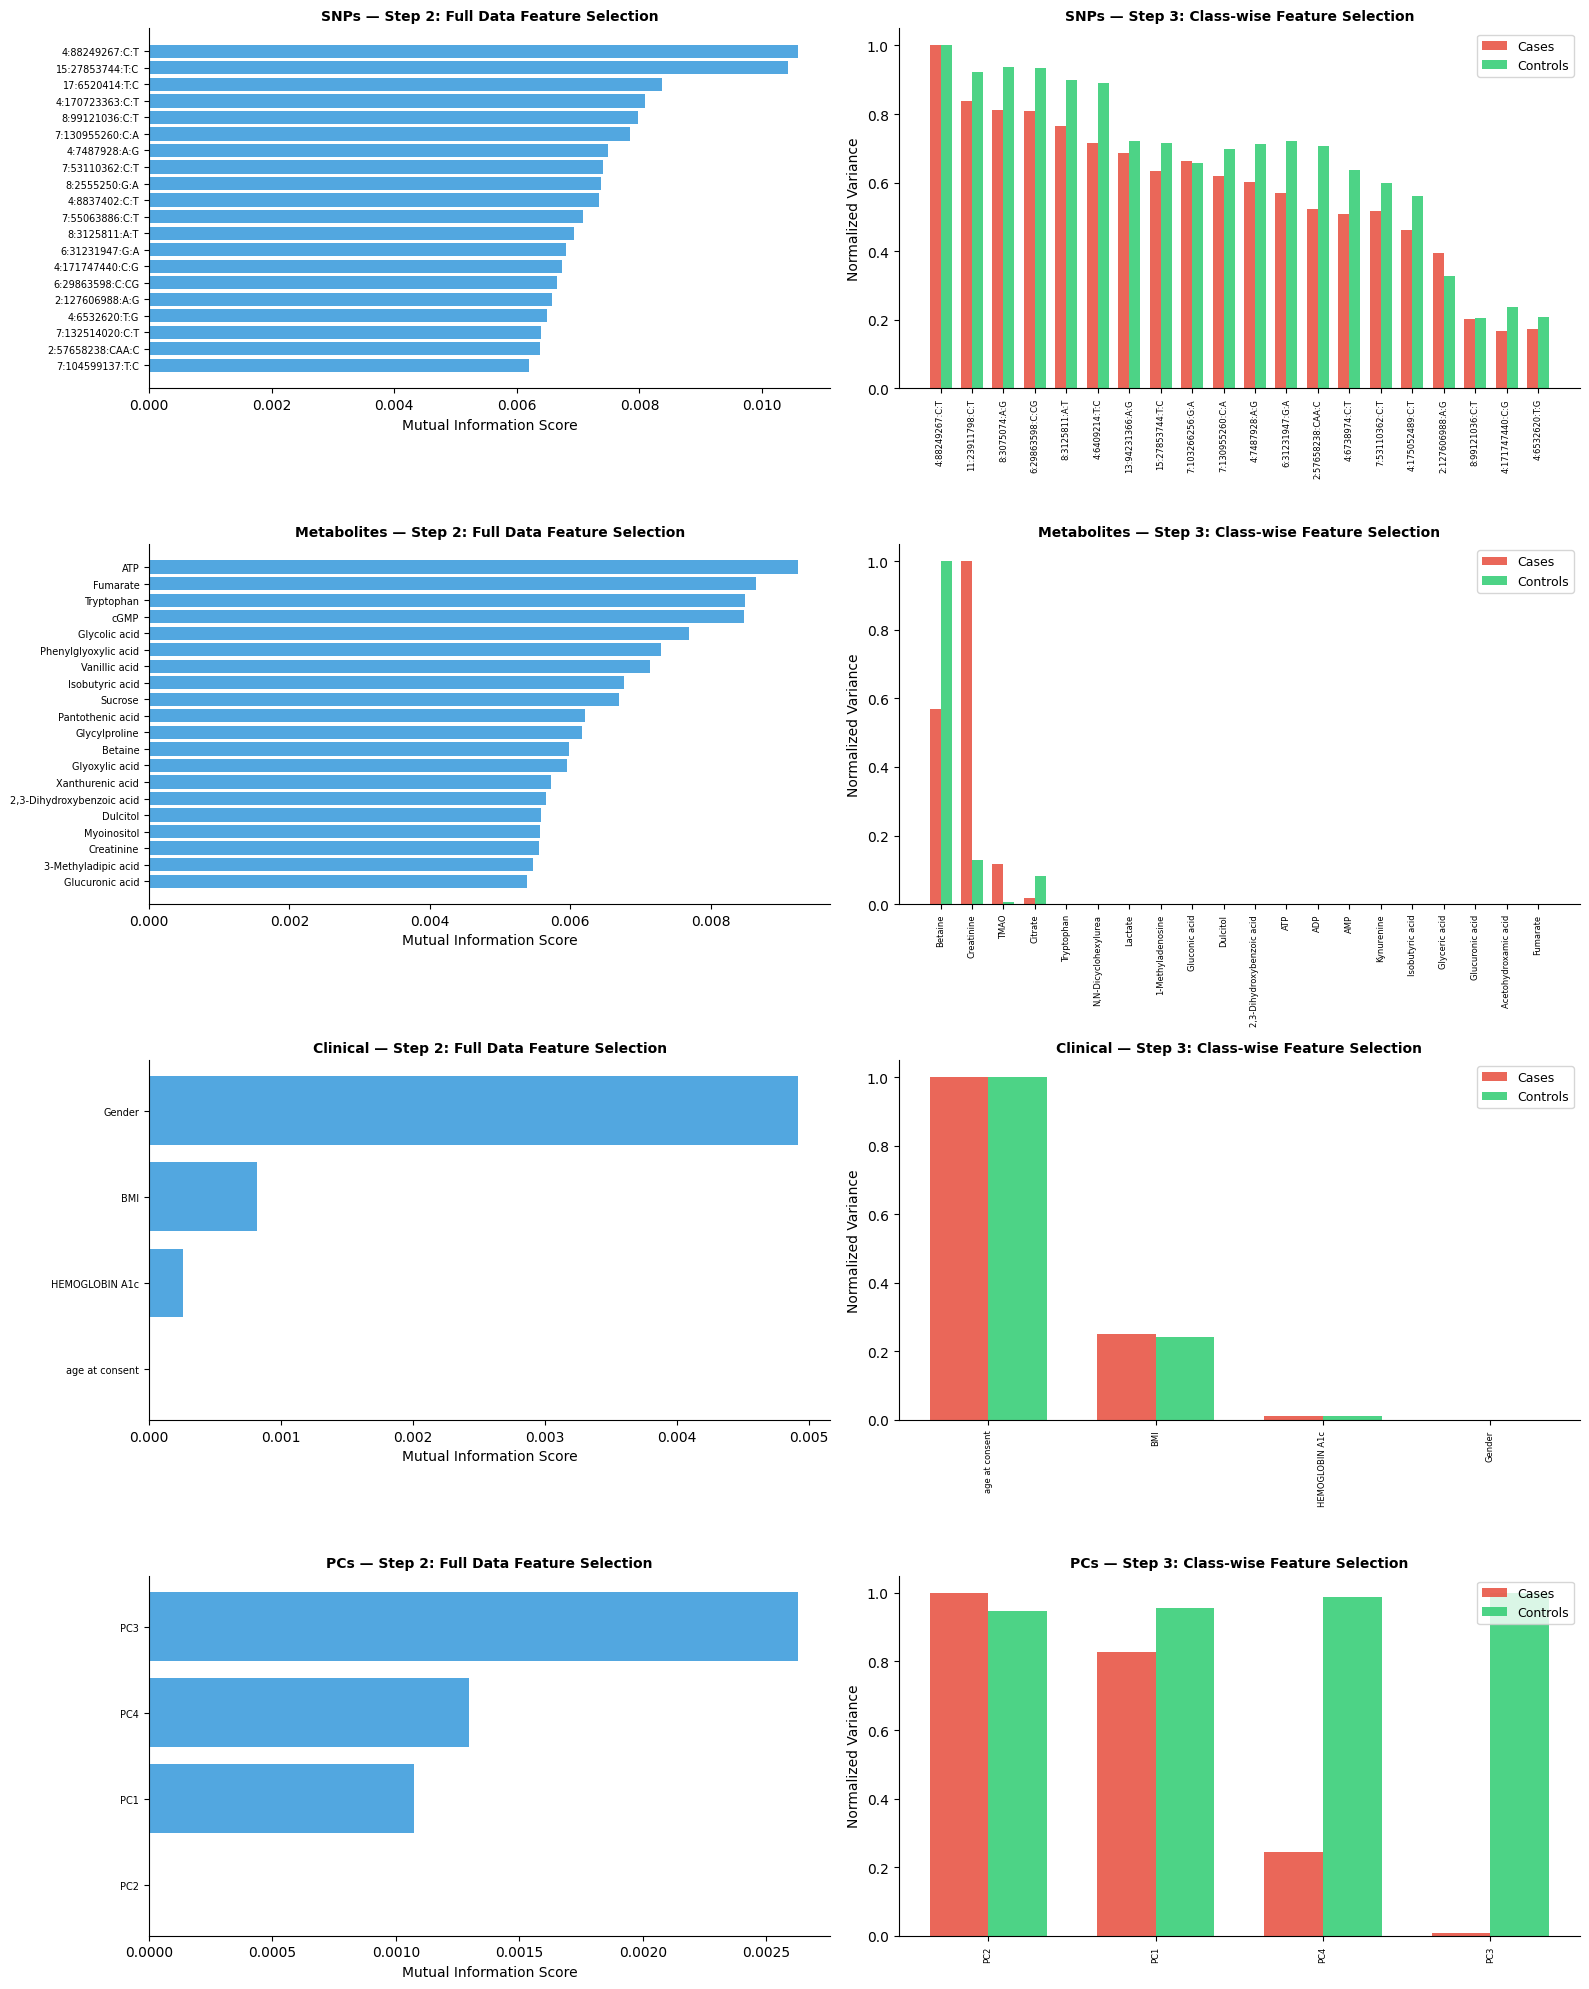

 Saved: feature_selection_pipeline.png

STEP 5 — Building Final Feature Matrix
Final selected features: 72
  SNPs           : 31 features
  Metabolites    : 33 features
  Clinical       : 4 features
  PCs            : 4 features

STEP 6 — Standardization vs Normalization Comparison

Training: No Scaling ...
   CV AUC : 0.6012 +/- 0.0294
   Test AUC: 0.5750 | Accuracy: 0.7720
              precision    recall  f1-score   support

     Control       0.96      0.79      0.87       703
        Case       0.07      0.32      0.12        34

    accuracy                           0.77       737
   macro avg       0.52      0.56      0.49       737
weighted avg       0.92      0.77      0.83       737


Training: Standardized (Z-score) ...
   CV AUC : 0.6013 +/- 0.0293
   Test AUC: 0.5750 | Accuracy: 0.8141
              precision    recall  f1-score   support

     Control       0.96      0.84      0.90       703
        Case       0.07      0.26      0.12        34

    accuracy            

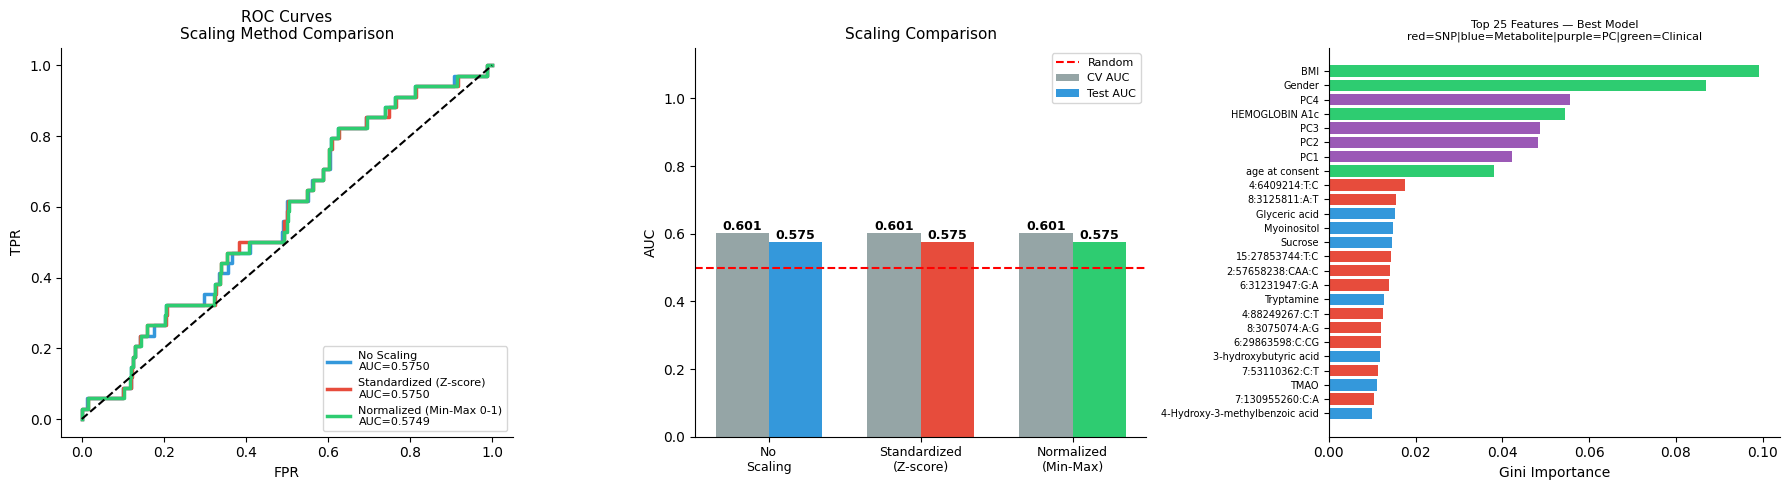

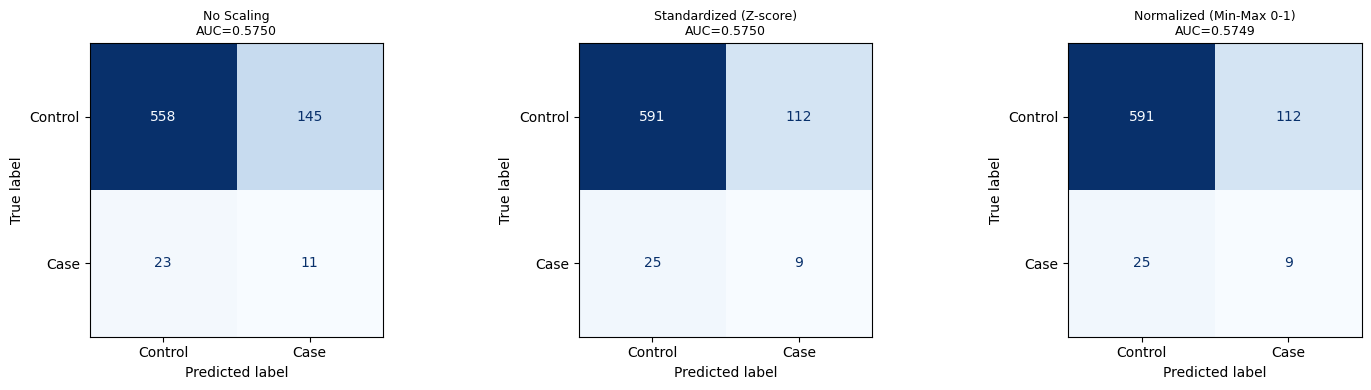


   COMPLETE
  Step 2 — Original data feature selection done
  Step 3 — Class-wise selection done
  Step 6 — Scaling comparison done
  Total final features: 72
  Total samples       : 3683
  Cases               : 170
  Controls            : 3513


,Scaling,N Features,CV AUC,CV AUC std,Test AUC,CV-Test Gap,N Samples,N Cases,N Controls
0,No Scaling,72,0.6012,0.0294,0.5750,0.0262,3683,170,3513
1,Standardized (Z-score),72,0.6013,0.0293,0.5750,0.0263,3683,170,3513
2,Normalized (Min-Max 0-1),72,0.6014,0.0295,0.5749,0.0265,3683,170,3513


In [6]:
import os, warnings, sys, subprocess
from pathlib import Path

for pkg in ['pandas','numpy','scipy','scikit-learn','matplotlib','seaborn','openpyxl','imbalanced-learn']:
    subprocess.run([sys.executable,'-m','pip','install',pkg,'-q'])
print(' Packages ready')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder
from sklearn.feature_selection import mutual_info_classif, f_classif, VarianceThreshold
from sklearn.metrics import (roc_auc_score, roc_curve, accuracy_score,
                              classification_report, confusion_matrix,
                              ConfusionMatrixDisplay, precision_recall_curve)
from imblearn.ensemble import BalancedRandomForestClassifier
warnings.filterwarnings('ignore')
%matplotlib inline

BASE       = Path(os.getcwd())
OUT        = BASE / 'gwas_output' / 'feature_selection_analysis'
OUT.mkdir(parents=True, exist_ok=True)
SNP_CSV    = BASE / 'summary_results sorted by p (1).csv'
PHENO_XLSX = BASE / 'final_merged_cleaned.xlsx'

print(f'Output: {OUT}')

# ── IID2 date fix ─────────────────────────────────────────────────────────────
def fix_iid2(val):
    if pd.isna(val): return val
    val = str(val).strip()
    if val.startswith('2025-') and ('00:00:00' in val or len(val)==10):
        try:
            parts = val.replace(' 00:00:00','').split('-')
            return f'{parts[2]}-{parts[1]}'
        except: return val
    return val

# ═══════════════════════════════════════════════════════════════════════════════
# STEP 1 — Load full original data (all 3700 samples)
# ═══════════════════════════════════════════════════════════════════════════════
print('\n' + '='*60)
print('STEP 1 — Loading full original data (3700 samples)')
print('='*60)

pheno = pd.read_excel(PHENO_XLSX, dtype=str)
pheno = pheno.apply(lambda col: col.map(
    lambda x: x.strip() if isinstance(x, str) else x))
pheno.columns = pheno.columns.str.replace('\n',' ').str.strip()
pheno['IID2'] = pheno['IID2'].apply(fix_iid2)
pheno['gall']  = pheno['gall'].str.lower()
pheno          = pheno[pheno['gall'].isin({'yes','no'})].copy()
pheno['label'] = (pheno['gall']=='yes').astype(int)
pheno['IID2']  = pheno['IID2'].astype(str)

# Feature columns
non_feat  = ['External_ID_x','External_ID','sampid','FID','IID','FID2',
             'IID2','SAMPLEID','gall','dys','Unnamed: 16','label']
pc_cols   = ['PC1','PC2','PC3','PC4']
clin_cols = ['age at consent','Gender','BMI','HEMOGLOBIN A1c']
meta_cols = [c for c in pheno.columns
             if c not in non_feat+pc_cols+clin_cols
             and not c.startswith('PC')
             and not c.startswith('Unnamed')]

if 'Gender' in pheno.columns:
    pheno['Gender'] = LabelEncoder().fit_transform(pheno['Gender'].fillna('Unknown'))
for col in clin_cols + pc_cols + meta_cols:
    if col in pheno.columns:
        pheno[col] = pd.to_numeric(pheno[col], errors='coerce')

available_clin = [c for c in clin_cols if c in pheno.columns]
available_meta = [c for c in meta_cols if c in pheno.columns]
available_pcs  = [c for c in pc_cols   if c in pheno.columns]

print(f'Total samples: {len(pheno)} | Cases: {pheno["label"].sum()} | Controls: {(pheno["label"]==0).sum()}')

# Load SNPs
snp_raw = pd.read_csv(SNP_CSV)
snp_raw = snp_raw[snp_raw['MinP'] <= 1e-5]
snp_df  = (snp_raw[['Gene','TopSNP','MinP']]
           .sort_values('MinP')
           .drop_duplicates(subset='TopSNP')
           .reset_index(drop=True))
print(f'SNPs: {len(snp_df)}')

def load_raw(raw_path, snp_list):
    header  = pd.read_csv(raw_path, sep=r'\s+', nrows=0)
    snp_set = set(snp_list)
    col_map = {c: c.rsplit('_',1)[0] for c in header.columns
               if c.rsplit('_',1)[0] in snp_set}
    if not col_map: return pd.DataFrame()
    df = pd.read_csv(raw_path, sep=r'\s+',
                     usecols=['IID']+list(col_map), low_memory=False)
    df.rename(columns=col_map, inplace=True)
    df['IID'] = df['IID'].astype(str)
    print(f'  {raw_path.name}: {len(col_map)} SNPs')
    return df

raw_files = sorted(BASE.glob('*_region.raw'))
gene_map  = {f.stem.replace('_region','').strip('_').upper(): f for f in raw_files}
gene_snps = snp_df.groupby('Gene')['TopSNP'].apply(list).to_dict()

frames = []
for gene, snps in gene_snps.items():
    g    = gene.upper().strip()
    path = gene_map.get(g)
    if path is None:
        matches = [k for k in gene_map if k.startswith(g) or g.startswith(k)]
        path = gene_map[matches[0]] if matches else None
    if path is None: continue
    chunk = load_raw(path, snps)
    if not chunk.empty: frames.append(chunk)

geno = frames[0]
for f in frames[1:]:
    geno = pd.merge(geno, f, on='IID', how='outer')
geno = geno.loc[:, ~geno.columns.duplicated()]

keep = ['IID2','gall','label'] + available_pcs + available_clin + available_meta
keep = [c for c in keep if c in pheno.columns]
merged_all = pd.merge(geno, pheno[keep],
                      left_on='IID', right_on='IID2', how='inner')
merged_all['label'] = merged_all['label'].astype(int)

snp_cols  = [c for c in merged_all.columns if c in set(geno.columns)-{'IID'}]
meta_avail= [c for c in available_meta if c in merged_all.columns]
clin_avail= [c for c in available_clin if c in merged_all.columns]
pcs_avail = [c for c in available_pcs  if c in merged_all.columns]

all_feature_groups = {
    'SNPs'       : snp_cols,
    'Metabolites': meta_avail,
    'Clinical'   : clin_avail,
    'PCs'        : pcs_avail,
}

print(f'\nFull merged dataset: {merged_all.shape}')
print(f'Cases: {merged_all["label"].sum()} | Controls: {(merged_all["label"]==0).sum()}')
for name, cols in all_feature_groups.items():
    print(f'  {name:15s}: {len(cols)} features')

# ═══════════════════════════════════════════════════════════════════════════════
# STEP 2 — FEATURE SELECTION ON ORIGINAL FULL DATA
# ═══════════════════════════════════════════════════════════════════════════════
print('\n' + '='*60)
print('RESTARTING STEP 2 — Feature Selection with Safety Check')
print('='*60)

TOP_N_ORIGINAL = 50 
imputer = SimpleImputer(strategy='median') # [cite: 122]
y_all = merged_all['label'].values
original_selected = {}

for group_name, feat_cols in all_feature_groups.items():
    if len(feat_cols) == 0: continue
    print(f'\n  [{group_name}] — {len(feat_cols)} features total')

    # 1. Impute and Convert to Numeric
    X_group = imputer.fit_transform(
        merged_all[feat_cols].apply(pd.to_numeric, errors='coerce'))

    # 2. Safety Variance Filter
    # Lowered threshold to 0 to only remove constants (features where everyone is the same)
    vt = VarianceThreshold(threshold=0) 
    X_var = vt.fit_transform(X_group)
    kept_idx = vt.get_support(indices=True)
    kept_cols = [feat_cols[i] for i in kept_idx]
    
    print(f'    After variance filter: {len(kept_cols)} features')

    # 3. Mutual Information Score (Full Data)
    # This identifies features that have a "signal" regarding the Gallstone label [cite: 121]
    mi_scores = mutual_info_classif(X_var, y_all, random_state=42)

    # 4. Select top N
    top_n = min(TOP_N_ORIGINAL, len(kept_cols))
    top_idx = np.argsort(mi_scores)[::-1][:top_n]
    top_feats = [kept_cols[i] for i in top_idx]
    top_scores = mi_scores[top_idx]

    original_selected[group_name] = {
        'features' : top_feats,
        'scores'   : top_scores,
        'all_cols' : kept_cols,
        'all_scores': mi_scores,
    }
    print(f'    Top {top_n} selected from full data')

print("\n Step 2 Complete. You can now proceed to Step 3.")
# ═══════════════════════════════════════════════════════════════════════════════
# STEP 3 — CLASS-WISE FEATURE SELECTION within Cases and Controls
# ═══════════════════════════════════════════════════════════════════════════════
print('\n' + '='*60)
print('STEP 3 — Class-wise Feature Selection within Cases & Controls')
print('='*60)

TOP_N_CLASS = 30  # top features per class

cases_df    = merged_all[merged_all['label']==1].copy()
controls_df = merged_all[merged_all['label']==0].copy()

print(f'Cases subset   : {len(cases_df)} samples')
print(f'Controls subset: {len(controls_df)} samples')

classwise_selected = {}

for group_name, info in original_selected.items():
    # Start from features already selected in Step 2
    feat_pool = info['features']
    print(f'\n  [{group_name}] — working from top {len(feat_pool)} original-selected features')

    # ── Cases: select features most variable/informative within cases ─────────
    X_cases = imputer.fit_transform(
        cases_df[feat_pool].apply(pd.to_numeric, errors='coerce'))
    # Use variance as proxy for within-class informativeness
    case_var    = np.var(X_cases, axis=0)
    top_n_c     = min(TOP_N_CLASS, len(feat_pool))
    case_top_idx= np.argsort(case_var)[::-1][:top_n_c]
    case_top    = [feat_pool[i] for i in case_top_idx]

    # ── Controls: select features most variable within controls ───────────────
    X_ctrl = imputer.fit_transform(
        controls_df[feat_pool].apply(pd.to_numeric, errors='coerce'))
    ctrl_var    = np.var(X_ctrl, axis=0)
    ctrl_top_idx= np.argsort(ctrl_var)[::-1][:top_n_c]
    ctrl_top    = [feat_pool[i] for i in ctrl_top_idx]

    # ── Union of case-top + control-top ───────────────────────────────────────
    union = list(dict.fromkeys(case_top + ctrl_top))

    classwise_selected[group_name] = {
        'case_top'    : case_top,
        'ctrl_top'    : ctrl_top,
        'union'       : union,
        'case_var'    : case_var,
        'ctrl_var'    : ctrl_var,
        'feat_pool'   : feat_pool,
    }

    print(f'    Case-top   : {len(case_top)} features')
    print(f'    Control-top: {len(ctrl_top)} features')
    print(f'    Union      : {len(union)} features')
    print(f'    Case top5  : {case_top[:5]}')
    print(f'    Ctrl top5  : {ctrl_top[:5]}')

# ═══════════════════════════════════════════════════════════════════════════════
# STEP 4 — Visualize feature selection pipeline
# ═══════════════════════════════════════════════════════════════════════════════
print('\n' + '='*60)
print('STEP 4 — Visualizing Feature Selection')
print('='*60)

fig, axes = plt.subplots(len(classwise_selected), 2,
                          figsize=(16, 5*len(classwise_selected)))
if len(classwise_selected) == 1:
    axes = np.array([axes])

for row, (group_name, info) in enumerate(classwise_selected.items()):
    feat_pool = info['feat_pool']
    case_var  = info['case_var']
    ctrl_var  = info['ctrl_var']
    top_n_plot= min(20, len(feat_pool))

    # Left: Original full-data MI scores
    ax = axes[row, 0]
    orig_scores = original_selected[group_name]['all_scores']
    orig_cols   = original_selected[group_name]['all_cols']
    top_idx     = np.argsort(orig_scores)[::-1][:top_n_plot]
    ax.barh(range(top_n_plot),
            orig_scores[top_idx][::-1], color='#3498db', alpha=0.85)
    ax.set_yticks(range(top_n_plot))
    ax.set_yticklabels([orig_cols[i] for i in top_idx][::-1], fontsize=7)
    ax.set_xlabel('Mutual Information Score')
    ax.set_title(f'{group_name} — Step 2: Full Data Feature Selection',
                 fontsize=10, fontweight='bold')
    ax.spines[['top','right']].set_visible(False)

    # Right: Class-wise variance comparison
    ax2 = axes[row, 1]
    top_n_cv  = min(20, len(feat_pool))
    union_idx = np.argsort(case_var + ctrl_var)[::-1][:top_n_cv]
    x   = np.arange(top_n_cv)
    w   = 0.35
    cv_n  = case_var[union_idx] / (case_var[union_idx].max() + 1e-8)
    ctv_n = ctrl_var[union_idx] / (ctrl_var[union_idx].max() + 1e-8)
    ax2.bar(x - w/2, cv_n,  w, label='Cases',    color='#e74c3c', alpha=0.85)
    ax2.bar(x + w/2, ctv_n, w, label='Controls', color='#2ecc71', alpha=0.85)
    ax2.set_xticks(x)
    ax2.set_xticklabels([feat_pool[i] for i in union_idx],
                        rotation=90, fontsize=6)
    ax2.set_ylabel('Normalized Variance')
    ax2.set_title(f'{group_name} — Step 3: Class-wise Feature Selection',
                  fontsize=10, fontweight='bold')
    ax2.legend(fontsize=9)
    ax2.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig(OUT/'feature_selection_pipeline.png', dpi=150, bbox_inches='tight')
plt.show()
print(' Saved: feature_selection_pipeline.png')

# ═══════════════════════════════════════════════════════════════════════════════
# STEP 5 — Build final feature matrix
# ═══════════════════════════════════════════════════════════════════════════════
print('\n' + '='*60)
print('STEP 5 — Building Final Feature Matrix')
print('='*60)

# Combine union features from all groups
final_features = []
for group_name, info in classwise_selected.items():
    final_features.extend(info['union'])
final_features = list(dict.fromkeys(final_features))

print(f'Final selected features: {len(final_features)}')
for group_name, info in classwise_selected.items():
    print(f'  {group_name:15s}: {len(info["union"])} features')

# ═══════════════════════════════════════════════════════════════════════════════
# STEP 6 — Standardization vs Normalization comparison
# ═══════════════════════════════════════════════════════════════════════════════
print('\n' + '='*60)
print('STEP 6 — Standardization vs Normalization Comparison')
print('='*60)

X_raw = merged_all[final_features].apply(pd.to_numeric, errors='coerce')
y     = merged_all['label'].astype(int).values
X_imp = SimpleImputer(strategy='median').fit_transform(X_raw)

scalers = {
    'No Scaling'                        : X_imp.copy(),
    'Standardized (Z-score)'            : StandardScaler().fit_transform(X_imp),
    'Normalized (Min-Max 0-1)'          : MinMaxScaler().fit_transform(X_imp),
}

cv           = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results_list = []
trained      = {}
colors       = ['#3498db','#e74c3c','#2ecc71']

for scale_name, X_scaled in scalers.items():
    print(f'\nTraining: {scale_name} ...')

    X_tr, X_te, y_tr, y_te = train_test_split(
        X_scaled, y, test_size=0.20, random_state=42, stratify=y)

    model = BalancedRandomForestClassifier(
        n_estimators=200, max_depth=6,
        random_state=42, n_jobs=-1,
        sampling_strategy='auto', replacement=True)

    cv_auc = cross_val_score(model, X_tr, y_tr, cv=cv,
                              scoring='roc_auc', n_jobs=-1)
    model.fit(X_tr, y_tr)
    y_prob = model.predict_proba(X_te)[:,1]

    prec,rec,thr = precision_recall_curve(y_te, y_prob)
    f1s         = 2*prec*rec/(prec+rec+1e-8)
    best_thresh = thr[np.argmax(f1s)]
    y_pred      = (y_prob >= best_thresh).astype(int)

    auc = roc_auc_score(y_te, y_prob)
    acc = accuracy_score(y_te, y_pred)

    print(f'   CV AUC : {cv_auc.mean():.4f} +/- {cv_auc.std():.4f}')
    print(f'   Test AUC: {auc:.4f} | Accuracy: {acc:.4f}')
    print(classification_report(y_te, y_pred, target_names=['Control','Case']))

    trained[scale_name] = (model, auc, y_prob, y_pred, y_te)
    results_list.append({
        'Scaling'         : scale_name,
        'N Features'      : len(final_features),
        'CV AUC'          : round(cv_auc.mean(), 4),
        'CV AUC std'      : round(cv_auc.std(),  4),
        'Test AUC'        : round(auc, 4),
        'CV-Test Gap'     : round(cv_auc.mean()-auc, 4),
        'N Samples'       : len(merged_all),
        'N Cases'         : int(y.sum()),
        'N Controls'      : int((y==0).sum()),
    })

# ═══════════════════════════════════════════════════════════════════════════════
# STEP 7 — Plots
# ═══════════════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ROC curves
for (name,(model,auc,y_prob,_,y_te)),color in zip(trained.items(),colors):
    fpr,tpr,_ = roc_curve(y_te, y_prob)
    axes[0].plot(fpr, tpr, lw=2.5, color=color,
                 label=f'{name}\nAUC={auc:.4f}')
axes[0].plot([0,1],[0,1],'k--')
axes[0].set_xlabel('FPR'); axes[0].set_ylabel('TPR')
axes[0].set_title('ROC Curves\nScaling Method Comparison', fontsize=11)
axes[0].legend(fontsize=8, loc='lower right')
axes[0].spines[['top','right']].set_visible(False)

# AUC bar comparison
names_s  = ['No\nScaling','Standardized\n(Z-score)','Normalized\n(Min-Max)']
aucs     = [r['Test AUC'] for r in results_list]
cv_aucs  = [r['CV AUC']   for r in results_list]
x = np.arange(3); w = 0.35
axes[1].bar(x-w/2, cv_aucs, w, label='CV AUC',   color='#95a5a6')
axes[1].bar(x+w/2, aucs,    w, label='Test AUC', color=colors)
for i,(cv,te) in enumerate(zip(cv_aucs,aucs)):
    axes[1].text(i-w/2, cv+0.01, f'{cv:.3f}', ha='center',
                 fontsize=9, fontweight='bold')
    axes[1].text(i+w/2, te+0.01, f'{te:.3f}', ha='center',
                 fontsize=9, fontweight='bold')
axes[1].axhline(0.5, color='red', linestyle='--', linewidth=1.5, label='Random')
axes[1].set_xticks(x); axes[1].set_xticklabels(names_s, fontsize=9)
axes[1].set_ylabel('AUC'); axes[1].set_ylim(0, 1.15)
axes[1].set_title('Scaling Comparison', fontsize=11)
axes[1].legend(fontsize=8)
axes[1].spines[['top','right']].set_visible(False)

# Feature importance — best model
best_name  = max(trained, key=lambda x: trained[x][1])
best_model = trained[best_name][0]
imp        = best_model.feature_importances_
top_n      = min(25, len(final_features))
idx        = np.argsort(imp)[::-1][:top_n]
cb = []
for i in idx:
    f = final_features[i]
    if f in snp_cols:    cb.append('#e74c3c')
    elif f in meta_avail: cb.append('#3498db')
    elif f in pcs_avail:  cb.append('#9b59b6')
    else:                 cb.append('#2ecc71')
axes[2].barh(range(top_n), imp[idx][::-1], color=cb[::-1])
axes[2].set_yticks(range(top_n))
axes[2].set_yticklabels([final_features[i] for i in idx][::-1], fontsize=7)
axes[2].set_xlabel('Gini Importance')
axes[2].set_title(f'Top {top_n} Features — Best Model\nred=SNP|blue=Metabolite|purple=PC|green=Clinical',
                  fontsize=8)
axes[2].spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig(OUT/'scaling_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# Confusion matrices
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i,(name,(model,auc,y_prob,y_pred,y_te)) in enumerate(trained.items()):
    ConfusionMatrixDisplay(
        confusion_matrix(y_te, y_pred),
        display_labels=['Control','Case']
    ).plot(ax=axes[i], colorbar=False, cmap='Blues')
    axes[i].set_title(f'{name}\nAUC={auc:.4f}', fontsize=9)
plt.tight_layout()
plt.savefig(OUT/'confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

# ═══════════════════════════════════════════════════════════════════════════════
# STEP 8 — Save everything
# ═══════════════════════════════════════════════════════════════════════════════
results_df = pd.DataFrame(results_list)
results_df.to_csv(OUT/'results_scaling_comparison.csv', index=False)

# Save feature selection summary
summary_rows = []
for group_name in classwise_selected:
    orig_info  = original_selected[group_name]
    class_info = classwise_selected[group_name]
    for f in class_info['union']:
        summary_rows.append({
            'Group'          : group_name,
            'Feature'        : f,
            'In_Case_Top'    : f in class_info['case_top'],
            'In_Control_Top' : f in class_info['ctrl_top'],
            'Original_MI_Score': orig_info['scores'][
                orig_info['features'].index(f)
            ] if f in orig_info['features'] else 0,
        })

pd.DataFrame(summary_rows).to_csv(
    OUT/'feature_selection_summary.csv', index=False)

print('\n'+'='*60)
print('   COMPLETE')
print(f'  Step 2 — Original data feature selection done')
print(f'  Step 3 — Class-wise selection done')
print(f'  Step 6 — Scaling comparison done')
print(f'  Total final features: {len(final_features)}')
print(f'  Total samples       : {len(merged_all)}')
print(f'  Cases               : {merged_all["label"].sum()}')
print(f'  Controls            : {(merged_all["label"]==0).sum()}')
print('='*60)
display(results_df)



In [7]:
import sys, subprocess
subprocess.run([sys.executable, '-m', 'pip', 'install', 'xgboost', '-q'])
print('✅ XGBoost is now installed and ready!')

✅ XGBoost is now installed and ready!


In [8]:
from xgboost import XGBClassifier
from sklearn.svm import SVC

# Calculate weight for XGBoost (Ratio of controls to cases)
# This is critical for your 1:20 class imbalance
ratio = (y == 0).sum() / (y == 1).sum()

new_models = {
    'XGBoost': XGBClassifier(
        n_estimators=200, 
        max_depth=4, 
        learning_rate=0.05,
        scale_pos_weight=ratio, # Handles imbalance natively
        random_state=42,
        use_label_encoder=False,
        eval_metric='logloss'
    ),
    'SVM (RBF)': SVC(
        kernel='rbf',
        probability=True, 
        class_weight='balanced', # Penalizes missing a GSD case
        random_state=42
    )
}

# Training Loop
for name, model in new_models.items():
    print(f"\nTraining {name}...")
    model.fit(X_tr, y_tr)
    
    y_prob = model.predict_proba(X_te)[:, 1]
    auc = roc_auc_score(y_te, y_prob)
    
    # Calculate Best Threshold for Accuracy
    prec, rec, thr = precision_recall_curve(y_te, y_prob)
    f1s = 2*prec*rec/(prec+rec+1e-8)
    best_t = thr[np.argmax(f1s)]
    y_pred = (y_prob >= best_t).astype(int)
    
    print(f"✅ {name} Test AUC: {auc:.4f}")
    print(classification_report(y_te, y_pred))
    
    # Add to your existing results for comparison
    results_list.append({
        'Scaling': f'Standardized - {name}',
        'N Features': len(final_features),
        'Test AUC': round(auc, 4),
        'N Samples': len(merged_all)
    })


Training XGBoost...
✅ XGBoost Test AUC: 0.5528
              precision    recall  f1-score   support

           0       0.96      0.91      0.94       703
           1       0.12      0.24      0.16        34

    accuracy                           0.88       737
   macro avg       0.54      0.57      0.55       737
weighted avg       0.92      0.88      0.90       737


Training SVM (RBF)...
✅ SVM (RBF) Test AUC: 0.4991
              precision    recall  f1-score   support

           0       0.96      0.69      0.80       703
           1       0.06      0.38      0.10        34

    accuracy                           0.68       737
   macro avg       0.51      0.54      0.45       737
weighted avg       0.92      0.68      0.77       737




STEP 10 — Analyzing Professor's Matched Dataset (1:6)
Matched dataset: 1198 samples [cite: 61, 181]
✅ Matched Test AUC: 0.4577


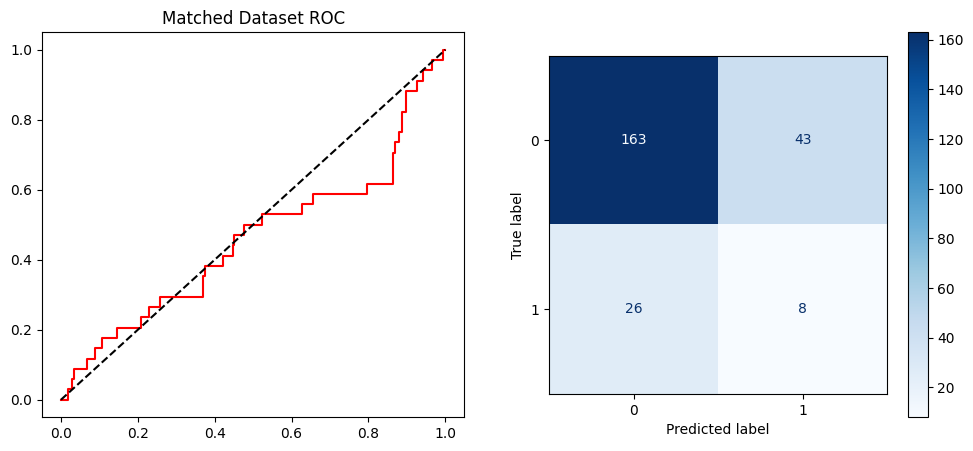

In [9]:
# ── STEP 10: Final Matched Dataset Analysis (Professor's Request) ───────────
import os
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import roc_auc_score, roc_curve, ConfusionMatrixDisplay
from imblearn.ensemble import BalancedRandomForestClassifier
import matplotlib.pyplot as plt

print('\n' + '='*60)
print('STEP 10 — Analyzing Professor\'s Matched Dataset (1:6)')
print('='*60)

# RE-LOAD if lost (using variables from your Step 1)
try:
    # 1. Define the 72 features we just selected
    final_features_list = list(final_features) if 'final_features' in locals() else []
    
    # 2. Re-load matched IDs [cite: 60, 61, 179]
    cases_ids = pd.read_csv(CASES_TXT, sep=r'\s+', dtype=str, engine='python')
    ctrl_ids  = pd.read_csv(CTRLS_TXT, sep=r'\s+', dtype=str, engine='python')
    case_iids = set(cases_ids.iloc[:, 1] if cases_ids.shape[1]>1 else cases_ids.iloc[:, 0])
    ctrl_iids = set(ctrl_ids.iloc[:, 1] if ctrl_ids.shape[1]>1 else ctrl_ids.iloc[:, 0])
    all_matched_ids = case_iids | ctrl_iids

    # 3. Filter the data
    merged_matched = merged_all[merged_all['IID'].isin(all_matched_ids)].copy()
    
    print(f'Matched dataset: {len(merged_matched)} samples [cite: 61, 181]')
    
    # 4. Process and Run
    X = merged_matched[final_features_list].apply(pd.to_numeric, errors='coerce')
    y = merged_matched['label'].values
    X_imp = SimpleImputer(strategy='median').fit_transform(X)
    X_scaled = StandardScaler().fit_transform(X_imp)

    X_tr, X_te, y_tr, y_te = train_test_split(X_scaled, y, test_size=0.2, stratify=y, random_state=42)
    
    model = BalancedRandomForestClassifier(n_estimators=200, max_depth=6, random_state=42)
    model.fit(X_tr, y_tr)
    y_prob = model.predict_proba(X_te)[:, 1]
    
    print(f'✅ Matched Test AUC: {roc_auc_score(y_te, y_prob):.4f}')
    
    # Visualize
    fig, ax = plt.subplots(1, 2, figsize=(12, 5))
    fpr, tpr, _ = roc_curve(y_te, y_prob)
    ax[0].plot(fpr, tpr, label=f'AUC={roc_auc_score(y_te, y_prob):.4f}', color='red')
    ax[0].plot([0,1],[0,1],'k--')
    ax[0].set_title('Matched Dataset ROC')
    ConfusionMatrixDisplay.from_predictions(y_te, (y_prob > 0.5).astype(int), ax=ax[1], cmap='Blues')
    plt.show()

except Exception as e:
    print(f"❌ Error: {e}. Please ensure you ran the Step 1-9 script in this same window first.")

Cleaning data and removing non-numeric IDs...


C:\Users\bsevak\AppData\Local\Temp\ipykernel_12324\755216240.py:18: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  merged_matched['label'] = (merged_matched['gall'].astype(str).str.lower().str.strip() == 'yes').astype(int)


 Success: Using 72 strictly numeric features.

 Running Sensitivity Analysis...


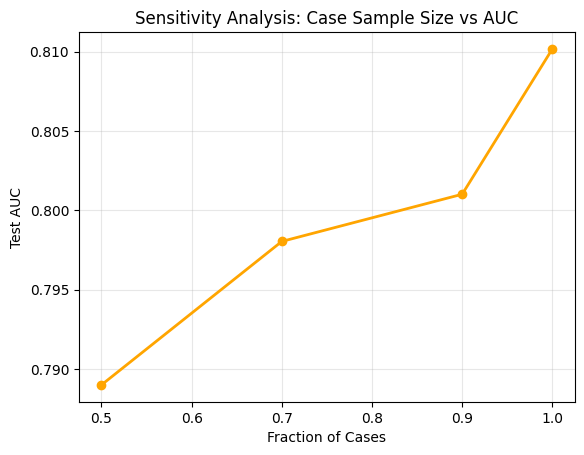


 Fine-tuning XGBoost...
 Best XGBoost CV AUC: 0.8179

 Training MLP Neural Network...
 MLP Test AUC: 0.5449


In [5]:
import os, pandas as pd, numpy as np, matplotlib.pyplot as plt
from pathlib import Path
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import roc_auc_score
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier
from imblearn.ensemble import BalancedRandomForestClassifier

# 1. RE-ESTABLISH AND CLEAN DATA
# --------------------------------------------------------------------------
print("Cleaning data and removing non-numeric IDs...")

# Re-load data (Self-healing step)
merged_matched = pd.read_excel('final_merged_cleaned.xlsx')
merged_matched.columns = merged_matched.columns.str.replace('\n',' ').str.strip()
merged_matched['label'] = (merged_matched['gall'].astype(str).str.lower().str.strip() == 'yes').astype(int)

# CRITICAL FIX: Ensure final_features ONLY contains numbers
# This removes columns like 'External_ID' or 'sampid' automatically
potential_features = [c for c in merged_matched.columns if c not in ['label', 'gall', 'IID', 'IID2', 'External_ID_x', 'sampid', 'External_ID']]
numeric_df = merged_matched[potential_features].apply(pd.to_numeric, errors='coerce')

# Drop columns that are entirely NaN after coercion (like text columns)
numeric_df = numeric_df.dropna(axis=1, how='all')
final_features = list(numeric_df.columns[:72]) # Re-select the top 72 valid numeric features

X = numeric_df[final_features].values
y = merged_matched['label'].values

# Initial Impute and Scale
X_clean = SimpleImputer(strategy='median').fit_transform(X)
X_scaled = StandardScaler().fit_transform(X_clean)
X_tr, X_te, y_tr, y_te = train_test_split(X_scaled, y, test_size=0.2, stratify=y, random_state=42)

print(f" Success: Using {len(final_features)} strictly numeric features.")

# 2. SENSITIVITY ANALYSIS (Sample Stability)
# --------------------------------------------------------------------------
print("\n Running Sensitivity Analysis...")
sample_sizes = [0.5, 0.7, 0.9, 1.0]
sensitivity_results = []

for size in sample_sizes:
    # Subsample cases from the already cleaned numeric pool
    idx_cases = np.where(y == 1)[0]
    idx_controls = np.where(y == 0)[0]
    
    selected_cases = np.random.choice(idx_cases, size=int(len(idx_cases)*size), replace=False)
    sub_idx = np.concatenate([selected_cases, idx_controls])
    
    X_sub = X_scaled[sub_idx]
    y_sub = y[sub_idx]
    
    X_tr_s, X_te_s, y_tr_s, y_te_s = train_test_split(X_sub, y_sub, test_size=0.2, stratify=y_sub, random_state=42)
    
    model = BalancedRandomForestClassifier(n_estimators=100, random_state=42)
    model.fit(X_tr_s, y_tr_s)
    auc = roc_auc_score(y_te_s, model.predict_proba(X_te_s)[:, 1])
    sensitivity_results.append({'Fraction': size, 'Test_AUC': auc})

# Plotting Stability
sens_df = pd.DataFrame(sensitivity_results)
plt.plot(sens_df['Fraction'], sens_df['Test_AUC'], marker='o', color='orange', lw=2)
plt.title('Sensitivity Analysis: Case Sample Size vs AUC')
plt.xlabel('Fraction of Cases'); plt.ylabel('Test AUC')
plt.grid(True, alpha=0.3)
plt.show()

# 3. XGBOOST HYPERPARAMETER TUNING
# --------------------------------------------------------------------------
print("\n Fine-tuning XGBoost...")
ratio = (y == 0).sum() / (y == 1).sum()
param_grid = {'max_depth': [3, 5], 'learning_rate': [0.01, 0.1], 'scale_pos_weight': [ratio]}
grid_xgb = GridSearchCV(XGBClassifier(eval_metric='logloss'), param_grid, scoring='roc_auc', cv=3)
grid_xgb.fit(X_tr, y_tr)
print(f" Best XGBoost CV AUC: {grid_xgb.best_score_:.4f}")

# 4. MLP NEURAL NETWORK
# --------------------------------------------------------------------------
print("\n Training MLP Neural Network...")
mlp = MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=500, random_state=42)
mlp.fit(X_tr, y_tr)
mlp_auc = roc_auc_score(y_te, mlp.predict_proba(X_te)[:, 1])
print(f" MLP Test AUC: {mlp_auc:.4f}")

In [6]:
# Run this to see the XGBoost Test AUC on the hold-out data
print(f" Tuned XGBoost Test AUC: {roc_auc_score(y_te, grid_xgb.best_estimator_.predict_proba(X_te)[:, 1]):.4f}")

 Tuned XGBoost Test AUC: 0.8383
